# \# Linear Regression

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# \# <i> Insurance dataset
## X feature are age, sex, bmi, children, smoker based on that predict charges

In [4]:
insurance_data = pd.read_csv("insurance.csv")
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [33]:
# visualization
# sns.scatterplot(data=insurance_data, x = "bmi", y = "charges", hue = "smoker
# plt.title("Bmi vs charges")

#feature engineering
X = insurance_data.drop(columns=["charges","region"])
y = insurance_data["charges"]

X["sex"] = X["sex"].map({"female":1, "male":0})
X["smoker"] = X["smoker"].map({"yes":1, "no":0})

In [34]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [35]:
# train model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
y_pred = model.predict(X_test)

In [37]:
# evalute matrix
# R ^ 2 score
r2 = r2_score(y_test, y_pred)
print("R^2 score : " , r2)

R^2 score :  0.7811302113434097


In [38]:
# adjested r square value
n = len(X_test)
p = len(X_test.columns)
adj_r2 = 1 - ((1-r2)*(n-1))/(n-p-1);
print("adjusted r2 score : ", adj_r2)

adjusted r2 score :  0.7769533069797343


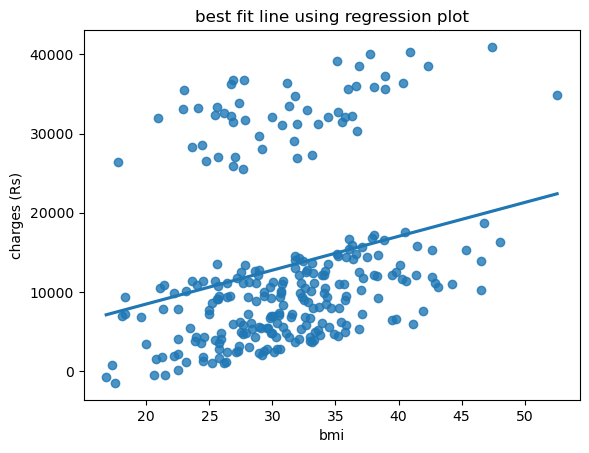

In [97]:

# visualization of best fit line
sns.regplot(
    x=X_test["bmi"],
    y=y_pred,
    scatter=True,
    ci=None
)

plt.title("best fit line using regression plot")
plt.ylabel("charges (Rs)")
plt.show()

# ## study hour and marks of students

In [167]:
study_hours = np.random.randint(1,11,1000).reshape(-1,1)
std_marks = (8 * study_hours + 15) + np.random.randint(-10,10,1000).reshape(-1,1)

In [168]:
model = LinearRegression()
model.fit(study_hours, std_marks)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [169]:
pred_marks = model.predict(study_hours)

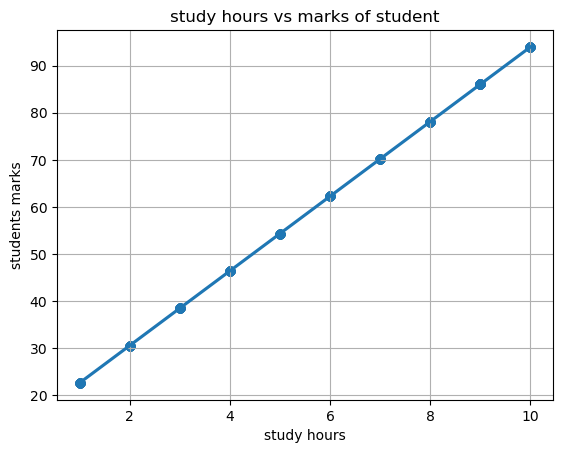

In [171]:
sns.regplot(x=study_hours, y = pred_marks)
plt.grid()
plt.title("study hours vs marks of student");
plt.xlabel("study hours")
plt.ylabel("students marks")
plt.show()

# \# House Pricing

In [267]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [268]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [269]:
house_dataset = pd.read_csv("HousePricePrediction.csv")

In [270]:
X = house_dataset.drop(columns=["SalePrice"])
y = house_dataset["SalePrice"]

#feature engineering

#one hot encoding
categorical_cols = [
    "MSZoning",
    "LotConfig",
    "BldgType",
    "Exterior1st"
]

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

# cleaning data
X = X.fillna(X.mean(numeric_only=True))
y = y.fillna(y.mean())

In [271]:
# train - test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [272]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [274]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("r2 is : " , r2)

r2 is :  0.3366572180561108


In [279]:
new_house = X.iloc[[0]].copy()
predicted_price = model.predict(new_house)

print("actual price : ", y.iloc[0])
print("Predicted Sale Price:", predicted_price[0])

actual price :  208500.0
Predicted Sale Price: 193798.74811127502


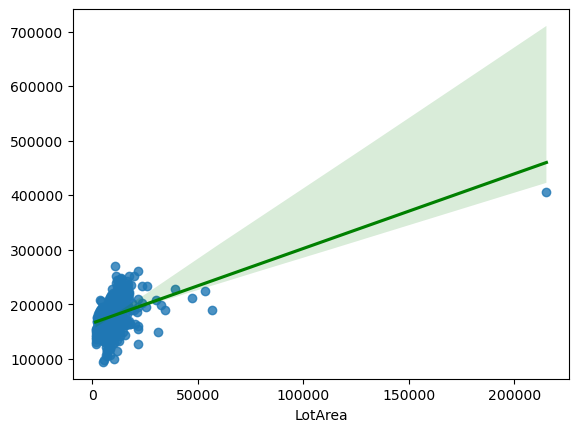

In [253]:

# visualiztion
sns.regplot(
    x=X_test["LotArea"],
    y=y_pred,
    scatter=True,
    line_kws={"color":"green"}
)
plt.show()

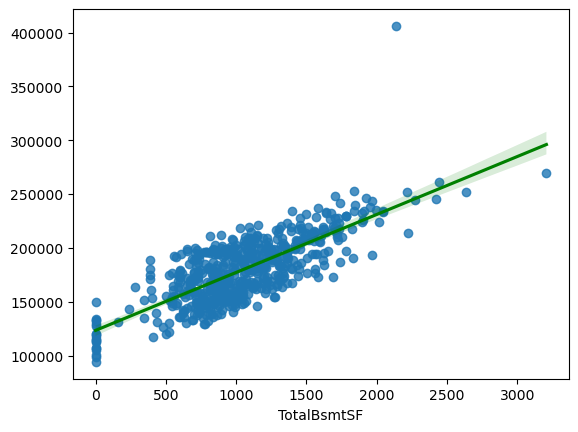

In [252]:
sns.regplot(
    x=X_test["TotalBsmtSF"],
    y=y_pred,
    scatter=True,
    line_kws={"color":"green"}
)
plt.show()

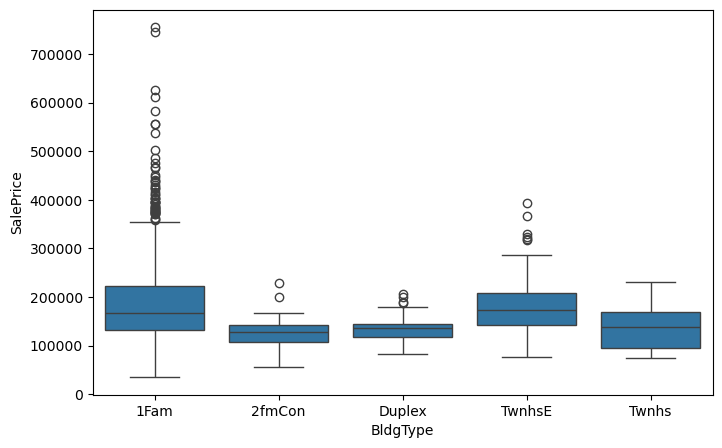

In [254]:
plt.figure(figsize=(8,5))
sns.boxplot(x=house_dataset["BldgType"], y=house_dataset["SalePrice"])
plt.show()